In [1]:
import xarray as xr
import yaml
import os
import sys

def read_config():
    config_path = 'local_config.yaml'
    try:
        with open(config_path, 'r') as f:
            try:
                localconfig = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(e)
                sys.exit(1)
            return localconfig
    except FileNotFoundError as e:
        print(e)
        print("You must set local_config.yaml in the main folder. Copy local_config-example.yaml and adjust appropriately.")
        sys.exit(1)


def get_data_paths():
    data_config_paths = 'data_paths.yaml'

    try:
        with open(data_config_paths, 'r') as f:
            try:
                all_data_paths = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(e)
                sys.exit(1)
    except FileNotFoundError as e:
        print(e)
        print("data_paths.yaml not found. Should exist in main folder")
        sys.exit(1)

    lc = read_config()
    data_paths = all_data_paths[lc['data_paths']]
    return data_paths

/home/m/matthewwright/nobackups/anaconda3/envs/initial-analysis/lib/python3.10/site-packages/xarray/backends/cfgrib_.py:29: UserWarning: Failed to load cfgrib - most likely there is a problem accessing the ecCodes library. Try `import cfgrib` to get the full error message
  warnings.warn(


In [2]:
fcst_yaml_path = "forecast.yaml"

In [7]:
with open(fcst_yaml_path, "r") as f:
    try:
        fcst_params = yaml.safe_load(f)
    except yaml.YAMLError as exc:
        print(exc)
        raise

output_folder = "/network/group/aopp/predict/AWH029_WRIGHT_S2SPREC/cGAN/forecasts/chenies_best_model"
save_crps_only = fcst_params["OUTPUT"]["save_crps_only"]
truth_input_folder = '/network/group/aopp/predict/AWH029_WRIGHT_S2SPREC/chenies_cropped_daily'

In [8]:
files = os.listdir(output_folder)

In [9]:
file_path = files[10] # Pick a random file

fcst = xr.load_dataset(f"{output_folder}/{file_path}")
fcst

/home/m/matthewwright/nobackups/anaconda3/envs/initial-analysis/lib/python3.10/site-packages/xarray/backends/plugins.py:71: RuntimeWarning: Engine 'cfgrib' loading failed:
libffi.so.7: cannot open shared object file: No such file or directory
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset>
Dimensions:          (y: 99, x: 99, member: 1000, time: 1, valid_time: 1)
Coordinates:
  * y                (y) float32 1.505e+05 1.515e+05 ... 2.475e+05 2.485e+05
  * x                (x) float32 4.505e+05 4.515e+05 ... 5.475e+05 5.485e+05
  * member           (member) int32 1 2 3 4 5 6 7 ... 995 996 997 998 999 1000
  * time             (time) datetime64[ns] 2023-06-21
Dimensions without coordinates: valid_time
Data variables:
    fcst_valid_time  (time, valid_time) datetime64[ns] 2023-06-22T06:00:00
    precipitation    (time, member, valid_time, y, x) float32 0.002679 ... 0....
    crps             (time, valid_time, y, x) float32 0.0006764 ... 0.002163
Attributes:
    description:  GAN 24-hour rainfall ensemble members in the ICPAC region.

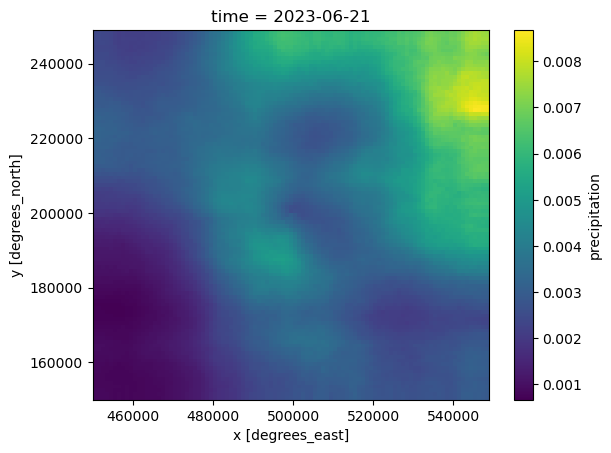

In [10]:
#plot precip if present
if not save_crps_only:
    fcst.precipitation.median('member').isel(valid_time=0, time=0).plot()

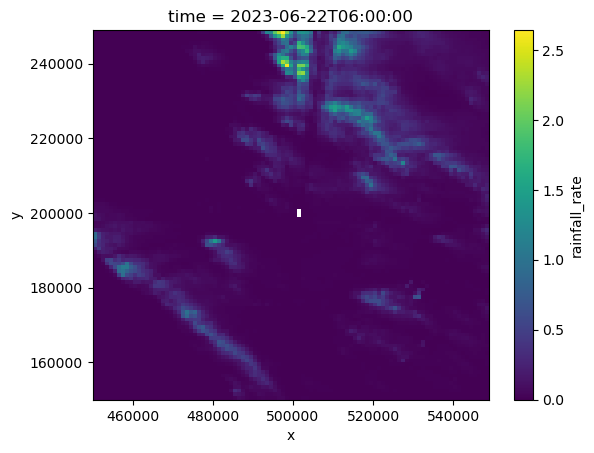

In [11]:
#plot truth
time = fcst.fcst_valid_time[0]
truth = xr.load_dataset(f"{truth_input_folder}/{str(time.dt.year.values[0])}/{time.dt.strftime('%Y%m%d').values[0]}_06.nc")
truth.rainfall_rate.isel(time=0).plot()


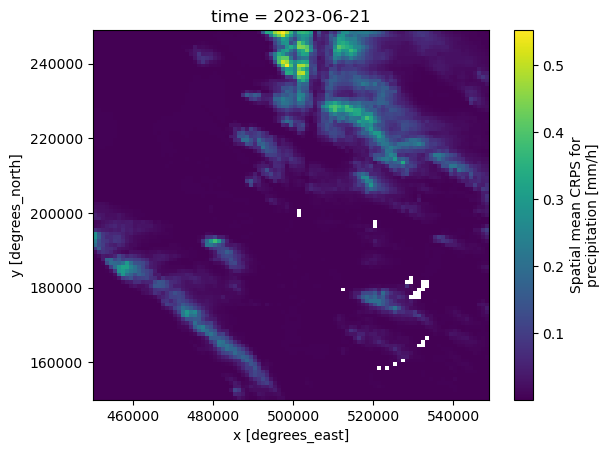

In [12]:
#plot crps
fcst.crps.isel(valid_time=0, time=0).plot()

In [13]:
#Plot CRPS
fcsts = xr.open_mfdataset(f"{output_folder}/*.nc", combine="by_coords")
fcsts = fcsts.where(fcsts.crps < 1e36) #remove missing values

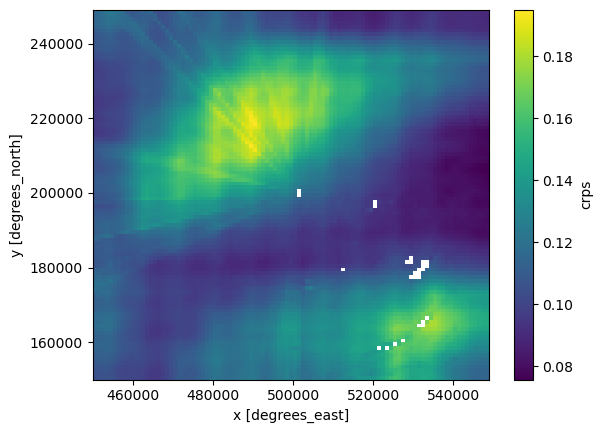

In [69]:
fcsts.crps.mean('time').plot()

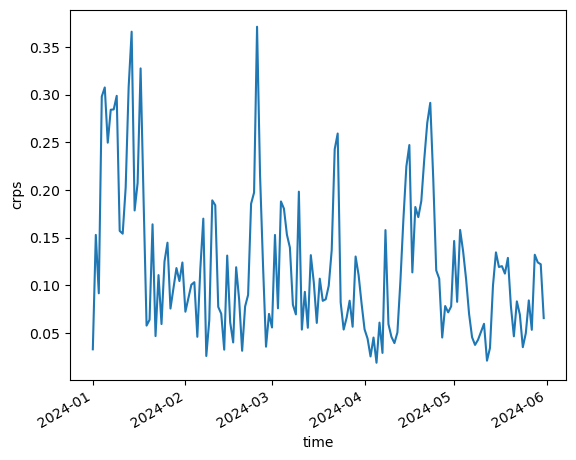

In [70]:
fcsts.crps.mean(('x','y')).plot()